In [63]:
import pandas as pd
import numpy as np

In [64]:
orders = pd.read_csv("/content/olist_orders_dataset.csv")

In [65]:
items = pd.read_csv("/content/olist_order_items_dataset.csv")
products = pd.read_csv("/content/olist_products_dataset.csv")
customers = pd.read_csv("/content/olist_customers_dataset.csv")
payments = pd.read_csv("/content/olist_order_payments_dataset.csv")
reviews = pd.read_csv("/content/olist_order_reviews_dataset.csv")
sellers = pd.read_csv("/content/olist_sellers_dataset.csv")
cat_trans = pd.read_csv("/content/product_category_name_translation.csv")

In [66]:
# Confirm all loaded successfully
tables = {'orders':orders,
          'items':items,
          'products':products,
          'customers':customers,
          'payments':payments,
          'reviews':reviews,
          'sellers':sellers,
          'cat_trans':cat_trans}

for name, df in tables.items():
    print(f"{name}: {df.shape[0]:,} rows | {df.shape[1]} columns")

orders: 99,441 rows | 8 columns
items: 112,650 rows | 7 columns
products: 32,951 rows | 9 columns
customers: 99,441 rows | 5 columns
payments: 103,886 rows | 5 columns
reviews: 99,224 rows | 7 columns
sellers: 3,095 rows | 4 columns
cat_trans: 71 rows | 2 columns


In [67]:
def profile_table(df, name):
    print(f"\n{'='*50}")
    print(f"TABLE: {name.upper()}")
    print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"Duplicate rows: {df.duplicated().sum()}")
    print("\nNull values:")
    nulls = df.isnull().sum()
    nulls_pct = (nulls / len(df) * 100).round(1)
    null_df = pd.DataFrame({'nulls':nulls, 'pct':nulls_pct})
    print(null_df[null_df['nulls'] > 0])
    print("\nData types:")
    print(df.dtypes)
    print("\nFirst 3 rows:")
    print(df.head(3))


# Run on every table
for name, df in tables.items():
    profile_table(df, name)



TABLE: ORDERS
Shape: 99,441 rows x 8 columns
Duplicate rows: 0

Null values:
                               nulls  pct
order_approved_at                160  0.2
order_delivered_carrier_date    1783  1.8
order_delivered_customer_date   2965  3.0

Data types:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

First 3 rows:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp order_approved_at  \
0    delivered          10/2/2017 10:5

In [68]:
# Validate Primary Keys

In [69]:
# orders table — order_id should be unique
print("orders — unique order_ids:", orders['order_id'].nunique())
print("orders — total rows:      ", len(orders))

# If both numbers match → order_id is a proper primary key


# payments table — one order can have MULTIPLE payment rows
print("\npayments — unique order_ids:", payments['order_id'].nunique())
print("payments — total rows:      ", len(payments))

# payments has MORE rows than unique order_ids
# This means one order can have 2+ payments (installments)
# So when you join payments to orders, you MUST aggregate first


orders — unique order_ids: 99441
orders — total rows:       99441

payments — unique order_ids: 99440
payments — total rows:       103886


In [70]:
#Aggregate payments BEFORE joining

# Aggregate payments: SUM payment_value per order
payments_agg = payments.groupby('order_id').agg(
    total_payment = ('payment_value', 'sum'),
    payment_type  = ('payment_type',  'first'),
    installments  = ('payment_installments', 'max')
).reset_index()

print("payments_agg shape:", payments_agg.shape)
# Should now have 1 row per order_id

payments_agg shape: (99440, 4)


In [71]:
# Translate product category names to English

# Merge translation into products table
products_en = products.merge(
    cat_trans,
    on='product_category_name',
    how='left'
)
# Use English name, fill missing with original Portuguese
products_en['category'] = products_en[
    'product_category_name_english'
].fillna(products_en['product_category_name'])

print(products_en[['product_id','category']].head(3))

                         product_id        category
0  1e9e8ef04dbcff4541ed26657ea517e5       perfumery
1  3aa071139cb16b67ca9e5dea641aaa2f             art
2  96bd76ec8810374ed1b65e291975717f  sports_leisure


In [72]:
#  Build master table step by step


# Start with orders (fact table)
master = orders.copy()
print(f"Start: {master.shape[0]:,} rows")

Start: 99,441 rows


In [73]:
# Add order items (price, freight, product_id, seller_id)
master = master.merge(
    items[['order_id','product_id','seller_id','price','freight_value']],
    on='order_id', how='inner'
)
print(f"After +items: {master.shape[0]:,} rows")

After +items: 112,650 rows


In [74]:
# Add product category (English)
master = master.merge(
    products_en[['product_id','category']],
    on='product_id', how='left'
)
print(f"After +products: {master.shape[0]:,} rows")

After +products: 112,650 rows


In [75]:
# Add customer state/city
master = master.merge(
    customers[['customer_id','customer_city','customer_state']],
    on='customer_id', how='left'
)
print(f"After +customers: {master.shape[0]:,} rows")

After +customers: 112,650 rows


In [76]:
# Add payment value
master = master.merge(
    payments_agg[['order_id','total_payment']],
    on='order_id', how='left'
)
print(f"After +payments: {master.shape[0]:,} rows")

After +payments: 112,650 rows


In [77]:
# Add review score
reviews_agg = reviews.groupby('order_id')['review_score'].first().reset_index()
master = master.merge(reviews_agg, on='order_id', how='left')
print(f"After +reviews: {master.shape[0]:,} rows")

After +reviews: 112,650 rows


In [78]:
# Final master table after merging
print(f"\nFinal master table: {master.shape}")


Final master table: (112650, 17)


In [79]:
master.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_id,seller_id,price,freight_value,category,customer_city,customer_state,total_payment,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,housewares,sao paulo,SP,38.71,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,perfumery,barreiras,BA,141.46,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/2018 8:38,8/8/2018 8:55,8/8/2018 13:50,8/17/2018 18:06,9/4/2018 0:00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,auto,vianopolis,GO,179.12,5.0


# Cleaning

In [80]:
# Convert date columns from text to datetime
date_cols = ['order_purchase_timestamp',
             'order_approved_at',
             'order_delivered_carrier_date',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    master[col] = pd.to_datetime(master[col], errors='coerce')

print("Date columns converted. Checking data types:")
print(master[date_cols].dtypes)

Date columns converted. Checking data types:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [81]:
# Extract time parts from purchase date


master['order_year']    = master['order_purchase_timestamp'].dt.year
master['order_month']   = master['order_purchase_timestamp'].dt.month
master['order_quarter'] = master['order_purchase_timestamp'].dt.quarter
master['month_label']   = master['order_purchase_timestamp'].dt.strftime('%Y-%m')
master['day_of_week']   = master['order_purchase_timestamp'].dt.day_name()
master['order_hour']    = master['order_purchase_timestamp'].dt.hour

print("\nTime columns created. Sample:")
print(master[['order_purchase_timestamp','order_year','order_month',
              'order_quarter','month_label',
              'day_of_week','order_hour']].head(3))


Time columns created. Sample:
  order_purchase_timestamp  order_year  order_month  order_quarter  \
0      2017-10-02 10:56:00        2017           10              4   
1      2018-07-24 20:41:00        2018            7              3   
2      2018-08-08 08:38:00        2018            8              3   

  month_label day_of_week  order_hour  
0     2017-10      Monday          10  
1     2018-07     Tuesday          20  
2     2018-08   Wednesday           8  


In [82]:
# Create all 5 KPI columns from date differences

In [83]:
# ─────────────────────────────────────────────
# STEP 3: Create KPI columns from date differences
# ─────────────────────────────────────────────

# KPI 1: Total delivery days — purchase to customer
master['delivery_days'] = (
    master['order_delivered_customer_date'] -
    master['order_purchase_timestamp']
).dt.days

# KPI 2: Approval hours — purchase to payment approved
master['approval_hours'] = (
    master['order_approved_at'] -
    master['order_purchase_timestamp']
).dt.total_seconds() / 3600

# KPI 3: Seller handling days — purchase to carrier pickup
master['seller_handling_days'] = (
    master['order_delivered_carrier_date'] -
    master['order_purchase_timestamp']
).dt.days

# KPI 4: Carrier delivery days — carrier pickup to customer
master['carrier_delivery_days'] = (
    master['order_delivered_customer_date'] -
    master['order_delivered_carrier_date']
).dt.days

# KPI 5: Early or late vs estimate
master['delivery_vs_estimate'] = (
    master['order_delivered_customer_date'] -
    master['order_estimated_delivery_date']
).dt.days

print("\nKPI columns created. Sample:")
print(master[['delivery_days','approval_hours',
              'seller_handling_days','carrier_delivery_days',
              'delivery_vs_estimate']].head(3))

print("\nKPI Summary:")
print(f"Avg delivery days        : {master['delivery_days'].mean():.1f}")
print(f"Avg approval hours       : {master['approval_hours'].mean():.1f}")
print(f"Avg seller handling days : {master['seller_handling_days'].mean():.1f}")
print(f"Avg carrier delivery days: {master['carrier_delivery_days'].mean():.1f}")
print(f"Avg days early/late      : {master['delivery_vs_estimate'].mean():.1f}")


KPI columns created. Sample:
   delivery_days  approval_hours  seller_handling_days  carrier_delivery_days  \
0            8.0        0.183333                   2.0                    6.0   
1           13.0       30.716667                   1.0                   12.0   
2            9.0        0.283333                   0.0                    9.0   

   delivery_vs_estimate  
0                  -8.0  
1                  -6.0  
2                 -18.0  

KPI Summary:
Avg delivery days        : 12.0
Avg approval hours       : 10.6
Avg seller handling days : 2.8
Avg carrier delivery days: 8.7
Avg days early/late      : -12.0


In [84]:
# Filter and remove bad data

print("\nShape BEFORE cleaning:", master.shape)

# Keep only delivered orders
master = master[master['order_status'] == 'delivered'].copy()
print("After keeping delivered only:", master.shape)

# Remove rows with negative delivery days (data entry error)
master = master[master['delivery_days'] >= 0]
print("After removing negative delivery days:", master.shape)

# Remove rows with negative seller handling days
master = master[master['seller_handling_days'] >= 0]
print("After removing negative handling days:", master.shape)

# Remove rows with negative carrier delivery days
master = master[master['carrier_delivery_days'] >= 0]
print("After removing negative carrier days:", master.shape)

# Remove rows where price is 0 or missing
master = master[master['price'] > 0]
print("After removing zero prices:", master.shape)

# Drop rows missing critical columns
master = master.dropna(subset=['price', 'customer_state',
                                'order_purchase_timestamp'])
print("After dropping critical nulls:", master.shape)

# Fill missing category with 'unknown'
master['category'] = master['category'].fillna('unknown')

# Fill missing review score with 0 (no review given)
master['review_score'] = master['review_score'].fillna(0)

# Fill missing approval_hours with median
median_approval = master['approval_hours'].median()
master['approval_hours'] = master['approval_hours'].fillna(median_approval)


Shape BEFORE cleaning: (112650, 28)
After keeping delivered only: (110197, 28)
After removing negative delivery days: (110189, 28)
After removing negative handling days: (110007, 28)
After removing negative carrier days: (109957, 28)
After removing zero prices: (109957, 28)
After dropping critical nulls: (109957, 28)


In [85]:
# Final check and save


print("\n===== FINAL MASTER TABLE =====")
print("Shape:", master.shape)

print("\nNull values remaining:")
remaining_nulls = master.isnull().sum()
print(remaining_nulls[remaining_nulls > 0])

print("\nNew columns created:")
new_cols = ['order_year','order_month','order_quarter',
            'month_label','day_of_week','order_hour',
            'delivery_days','approval_hours',
            'seller_handling_days','carrier_delivery_days',
            'delivery_vs_estimate']
print(master[new_cols].describe().round(1))



===== FINAL MASTER TABLE =====
Shape: (109957, 28)

Null values remaining:
order_approved_at    15
total_payment         3
dtype: int64

New columns created:
       order_year  order_month  order_quarter  order_hour  delivery_days  \
count    109957.0     109957.0       109957.0    109957.0       109957.0   
mean       2017.5          6.0            2.4        14.8           12.0   
std           0.5          3.2            1.1         5.3            9.5   
min        2016.0          1.0            1.0         0.0            0.0   
25%        2017.0          3.0            1.0        11.0            6.0   
50%        2018.0          6.0            2.0        15.0           10.0   
75%        2018.0          8.0            3.0        19.0           15.0   
max        2018.0         12.0            4.0        23.0          209.0   

       approval_hours  seller_handling_days  carrier_delivery_days  \
count        109957.0              109957.0               109957.0   
mean            

In [86]:
# Save the file
master.to_csv('master_clean_olist.csv', index=False)

# Download it directly to your computer
from google.colab import files
files.download('master_clean_olist.csv')

print("\n Saved: olist_master_clean.csv")
print("This file is ready to import into Power BI")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Saved: olist_master_clean.csv
This file is ready to import into Power BI


# Calculated all KPI's

# Visualization

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
os.makedirs('outputs', exist_ok=True)

print("Setup complete")
print("Outputs folder ready")

Setup complete
Outputs folder ready


Monthly Revenue Table:
      Month    Revenue  MoM_Growth_%
0   2016-09     134.97           NaN
1   2016-10   39738.17  2.934222e+04
2   2016-12      10.90 -9.997257e+01
3   2017-01  111609.71  1.023842e+06
4   2017-02  233832.81  1.095094e+02
5   2017-03  359109.85  5.357548e+01
6   2017-04  340669.68 -5.134966e+00
7   2017-05  488869.27  4.350243e+01
8   2017-06  421781.48 -1.372305e+01
9   2017-07  480004.62  1.380410e+01
10  2017-08  554227.91  1.546304e+01
11  2017-09  607220.67  9.561547e+00
12  2017-10  648247.65  6.756519e+00
13  2017-11  987648.07  5.235660e+01
14  2017-12  726033.19 -2.648867e+01
15  2018-01  924645.00  2.735575e+01
16  2018-02  826437.13 -1.062114e+01
17  2018-03  953356.25  1.535738e+01
18  2018-04  972528.54  2.011031e+00
19  2018-05  974791.41  2.326790e-01
20  2018-06  850257.55 -1.277544e+01
21  2018-07  863733.42  1.584916e+00
22  2018-08  833262.47 -3.527819e+00


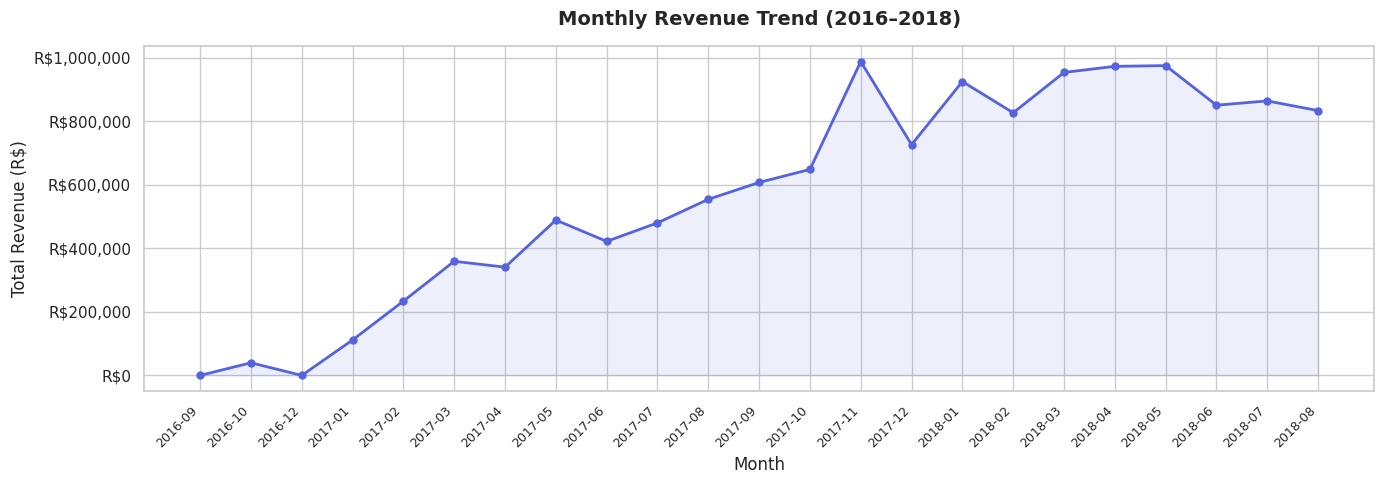

Chart 1 saved: outputs/monthly_revenue.png


In [88]:
# CHART 1: Monthly Revenue Trend


# Step 1: Group by month and sum revenue
monthly = master.groupby('month_label')['price'].sum().reset_index()

# Step 2: Sort chronologically
monthly = monthly.sort_values('month_label').reset_index(drop=True)

# Step 3: Rename columns
monthly.columns = ['Month', 'Revenue']

# Step 4: Calculate Month over Month growth
monthly['MoM_Growth_%'] = monthly['Revenue'].pct_change() * 100

print("Monthly Revenue Table:")
print(monthly)

# Step 5: Draw chart
fig, ax = plt.subplots(figsize=(14, 5))

# Draw line
ax.plot(monthly['Month'], monthly['Revenue'],
        marker='o',
        linewidth=2,
        color='#5563DE',
        markersize=5)

# Fill area under line
ax.fill_between(range(len(monthly)),
                monthly['Revenue'],
                alpha=0.1,
                color='#5563DE')

# Fix X axis labels
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['Month'],
                   rotation=45,
                   ha='right',
                   fontsize=9)

# Title and labels
ax.set_title('Monthly Revenue Trend (2016–2018)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (R$)')

# Format Y axis with R$ and commas
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'R${x:,.0f}')
)

plt.tight_layout()
plt.savefig('outputs/monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved: outputs/monthly_revenue.png")

Top 10 Categories:
                 Category     Revenue
43          health_beauty  1231510.16
73          watches_gifts  1163951.82
7          bed_bath_table  1021560.81
67         sports_leisure   952933.61
15  computers_accessories   887550.11
39        furniture_decor   709154.01
49             housewares   614575.06
20             cool_stuff   609891.23
5                    auto   577489.96
71                   toys   470510.75


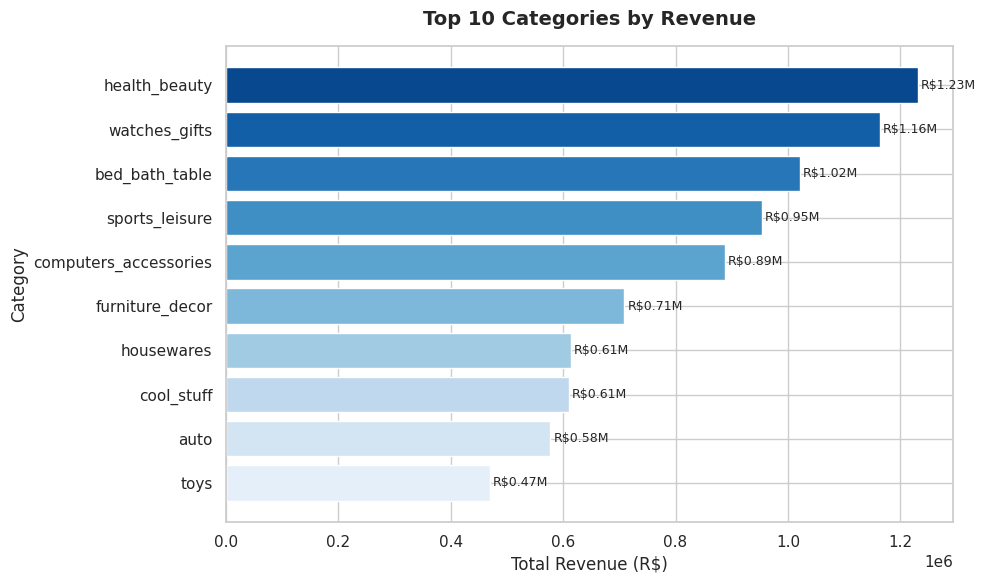

Chart 2 saved: outputs/category_revenue.png


In [89]:
# CHART 2: Top 10 Categories by Revenue

# Step 1: Group and get top 10
cat_rev = (master.groupby('category')['price']
                 .sum()
                 .reset_index()
                 .sort_values('price', ascending=False)
                 .head(10))

cat_rev.columns = ['Category', 'Revenue']

print("Top 10 Categories:")
print(cat_rev)

# Step 2: Draw chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette('Blues_r', len(cat_rev))

bars = ax.barh(cat_rev['Category'],
               cat_rev['Revenue'],
               color=colors)

# Add value labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 5000,
            bar.get_y() + bar.get_height() / 2,
            f'R${width/1e6:.2f}M',
            va='center',
            fontsize=9)

# Highest revenue on top
ax.invert_yaxis()

ax.set_title('Top 10 Categories by Revenue',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Revenue (R$)')
ax.set_ylabel('Category')

plt.tight_layout()
plt.savefig('outputs/category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved: outputs/category_revenue.png")

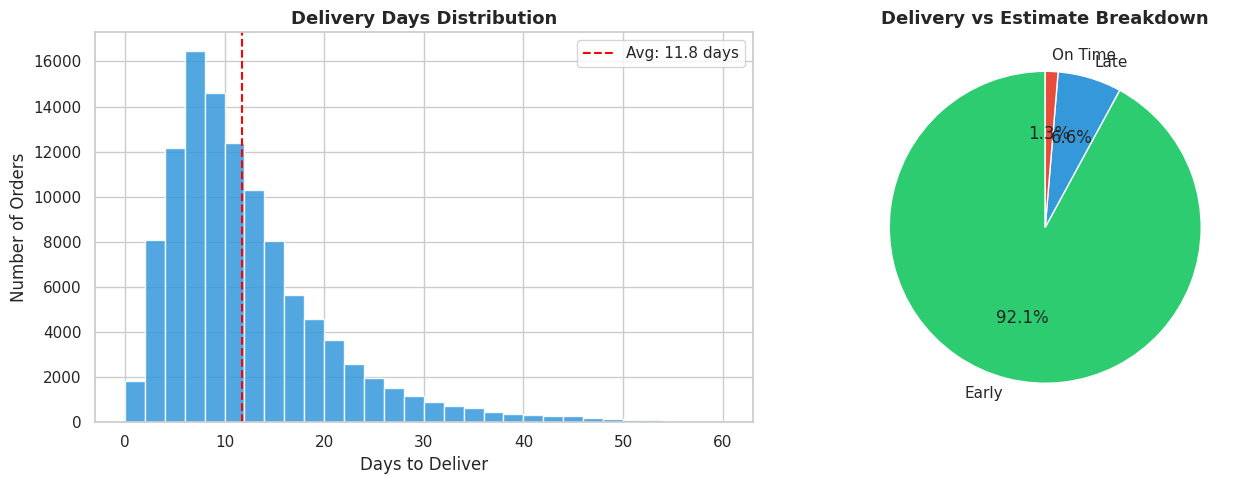

Chart 3 saved: outputs/delivery_analysis.png


In [90]:
# CHART 3: Delivery Analysis


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left chart: Delivery days histogram ──
ax1 = axes[0]

# Filter extreme outliers for chart only
delivery_clean = master['delivery_days'][
    (master['delivery_days'] >= 0) &
    (master['delivery_days'] <= 60)
]

ax1.hist(delivery_clean,
         bins=30,
         color='#3498DB',
         edgecolor='white',
         alpha=0.85)

# Red dashed line at average
ax1.axvline(delivery_clean.mean(),
            color='red',
            linestyle='--',
            linewidth=1.5,
            label=f'Avg: {delivery_clean.mean():.1f} days')

ax1.set_title('Delivery Days Distribution',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Days to Deliver')
ax1.set_ylabel('Number of Orders')
ax1.legend()

# ── Right chart: Early vs Late pie chart ──
ax2 = axes[1]

delivery_status = master['delivery_vs_estimate'].apply(
    lambda x: 'Early' if x < 0 else ('On Time' if x == 0 else 'Late')
)
status_counts = delivery_status.value_counts()

colors_pie = ['#2ECC71', '#3498DB', '#E74C3C']

ax2.pie(status_counts.values,
        labels=status_counts.index,
        autopct='%1.1f%%',
        colors=colors_pie,
        startangle=90)

ax2.set_title('Delivery vs Estimate Breakdown',
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/delivery_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved: outputs/delivery_analysis.png")

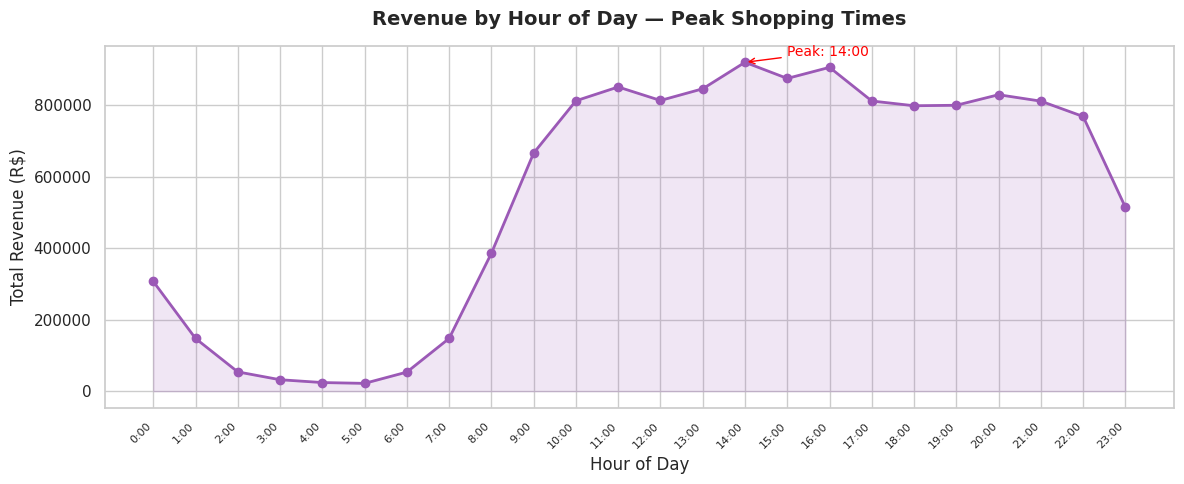

Chart 4 saved: outputs/peak_hours.png


In [91]:
# CHART 4: Peak Shopping Hours


# Group by hour
hourly = master.groupby('order_hour')['price'].sum().reset_index()
hourly.columns = ['Hour', 'Revenue']

# Draw chart
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(hourly['Hour'], hourly['Revenue'],
        marker='o',
        linewidth=2,
        color='#9B59B6',
        markersize=6)

ax.fill_between(hourly['Hour'], hourly['Revenue'],
                alpha=0.15,
                color='#9B59B6')

# Find and annotate peak hour
peak_hour = hourly.loc[hourly['Revenue'].idxmax(), 'Hour']
peak_rev  = hourly['Revenue'].max()

ax.annotate(f'Peak: {peak_hour}:00',
            xy=(peak_hour, peak_rev),
            xytext=(peak_hour + 1, peak_rev * 1.02),
            fontsize=10,
            color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

# X axis — show all 24 hours
ax.set_xticks(range(0, 24))
ax.set_xticklabels([f'{h}:00' for h in range(0, 24)],
                    rotation=45,
                    ha='right',
                    fontsize=8)

ax.set_title('Revenue by Hour of Day — Peak Shopping Times',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Total Revenue (R$)')

plt.tight_layout()
plt.savefig('outputs/peak_hours.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved: outputs/peak_hours.png")

In [92]:
# KPI CALCULATIONS -

total_revenue = master['price'].sum()
total_orders = master['order_id'].nunique()
aov = total_revenue / total_orders
avg_delivery = master['delivery_days'].mean()
avg_review = master['review_score'].mean()
avg_approval = master['approval_hours'].mean()

on_time = (master['delivery_vs_estimate'] <= 0).sum()
on_time_rate = on_time / len(master) * 100

avg_handling = master['seller_handling_days'].mean()

print("KPIs recalculated successfully")
print(f"Total Revenue: R$ {total_revenue:,.2f}")

KPIs recalculated successfully
Total Revenue: R$ 13,198,150.72


In [93]:
# EXPORT SUMMARY CSVs FOR POWER BI


# Monthly summary
monthly.to_csv('outputs/monthly_summary.csv', index=False)
print("monthly_summary.csv saved")

# Category summary with extra details
cat_summary = master.groupby('category').agg(
    revenue      = ('price',         'sum'),
    orders       = ('order_id',      'nunique'),
    avg_review   = ('review_score',  'mean'),
    avg_delivery = ('delivery_days', 'mean')
).reset_index()
cat_summary = cat_summary.sort_values('revenue', ascending=False)
cat_summary.to_csv('outputs/category_summary.csv', index=False)
print("category_summary.csv saved")

# State summary for Power BI map
state_summary = master.groupby('customer_state').agg(
    revenue = ('price',    'sum'),
    orders  = ('order_id', 'nunique')
).reset_index()
state_summary.to_csv('outputs/state_summary.csv', index=False)
print("state_summary.csv saved")

# Hourly summary
hourly.to_csv('outputs/hourly_summary.csv', index=False)
print("hourly_summary.csv saved")

# KPI summary
kpi_summary = {
    'KPI': [
        'Total Revenue (R$)',
        'Total Orders',
        'Avg Order Value (R$)',
        'Avg Delivery Days',
        'Avg Approval Hours',
        'Avg Seller Handling Days',
        'Avg Review Score',
        'On Time Delivery Rate (%)'
    ],
    'Value': [
        round(total_revenue, 2),
        total_orders,
        round(aov, 2),
        round(avg_delivery, 1),
        round(avg_approval, 1),
        round(avg_handling, 1),
        round(avg_review, 2),
        round(on_time_rate, 1)
    ]
}

import pandas as pd
kpi_df = pd.DataFrame(kpi_summary)
kpi_df.to_csv('outputs/kpi_summary.csv', index=False)
print("kpi_summary.csv saved")

print("\nAll files in outputs folder:")
for f in os.listdir('outputs'):
    size = os.path.getsize(f'outputs/{f}')
    print(f"  {f} — {size/1024:.1f} KB")

monthly_summary.csv saved
category_summary.csv saved
state_summary.csv saved
hourly_summary.csv saved
kpi_summary.csv saved

All files in outputs folder:
  category_revenue.png — 83.6 KB
  hourly_summary.csv — 0.3 KB
  kpi_summary.csv — 0.2 KB
  state_summary.csv — 0.5 KB
  delivery_analysis.png — 82.3 KB
  monthly_summary.csv — 0.8 KB
  category_summary.csv — 4.8 KB
  peak_hours.png — 83.1 KB
  monthly_revenue.png — 89.4 KB


In [94]:
# DOWNLOAD ALL FILES TO YOUR COMPUTER

from google.colab import files

print("Starting downloads...")

# Download all files from outputs folder automatically
for filename in os.listdir('outputs'):
    filepath = f'outputs/{filename}'
    files.download(filepath)
    print(f"Downloaded: {filename}")

print("\n Phase 5 complete!")
print("All files downloaded to your Downloads folder")
print("Next step: Open Power BI and import these CSV files")

Starting downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: category_revenue.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: peak_hours.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: monthly_revenue.png

 Phase 5 complete!
All files downloaded to your Downloads folder
Next step: Open Power BI and import these CSV files


In [95]:
master['category'] = master['category'].str.replace('_', ' ').str.title()
master.to_csv('olist_master_clean.csv', index=False)

from google.colab import files
files.download('olist_master_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>